# Planet: a knob in, a world out

*A guided what-if over the capstone — the latitudinal climate of a planet, and the bands of life it sets.*

You turn two planetary knobs — **how bright the sun is** and **how much greenhouse gas is in the
air** — and the model hands back a whole world: a pole-to-equator **temperature profile**, and the
**bands of life** that profile permits. This notebook walks that chain end to end and lets you turn
the knobs: the solar constant, the greenhouse (OLR) offset, the efficiency of heat transport.

Every number here comes from a function **validated in isolation** (`projects/planet/…`, each with
its own test triad — an analytic limit, a conservation/consistency law, a published benchmark). The
notebook is a *thin skin* (per [ADR 0002](../../docs/decisions/0002-visualization-and-ux.md)): each
compute cell calls the headless module directly, then `ipywidgets` sliders re-run that same code
live. The figures *consume* validated arrays — they are reach, not evidence.

The arc — the climate, the bifurcation it hides, and the life it sets:

1. **The climate spine** — the latitudinal **energy-balance model** → the temperature profile
   `T(φ)` (`ebm`, `albedo`).
2. **The Snowball bifurcation** — one knob (the sun), **two stable climates**, a catastrophic jump
   (`demo_snowball`).
3. **Climate → habitability** — precip + the **Whittaker classifier** → the **biome map**
   (`precip`, `biomes`, `demo_biomes`).
4. **The deep end** — the interactive 3-D globe (`planetmap`), and what comes next.

> This is the capstone, and it reuses the **frozen `engines/diffusion` solver a third time** — the
> same parabolic solver that cooled Steel's Jominy bar and diffused Chip's dopant, now as a sphere's
> **pole-to-equator heat transport**. Units are **SI / climlab-conventional**: W m⁻², °C,
> precipitation in cm/yr, and `x = sin φ` (the equal-area coordinate).

## Setup

Imports + the inline backend. The bootstrap walks up to the repo root so `projects.planet…` imports
whether you launched Jupyter from the repo root or from `projects/planet/`. Needs the `viz` +
`notebook` extras: `pip install -e .[viz,notebook]`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Make `projects.planet…` importable regardless of the launch directory.
for _root in (Path.cwd(), *Path.cwd().parents):
    if (_root / "pyproject.toml").exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break

from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from projects.planet import ebm, albedo, precip, biomes
from projects.planet import demo_snowball, demo_biomes
from projects.planet.albedo import EBMParams, present_day_climate
from projects.planet.ebm import A_OLR, S0_EARTH, D_TRANSPORT, T_FREEZE
from projects.planet.biomes import Biome, BIOME_NAMES
from projects.planet.plots import profile_axes, snowball_figure, biomes_figure

print(f"present-day defaults:  S₀ = {S0_EARTH:.1f} W/m²,  OLR offset A = {A_OLR:.0f} W/m²,  "
      f"transport D = {D_TRANSPORT:.3f} W/m²/K")

present-day defaults:  S₀ = 1365.2 W/m²,  OLR offset A = 210 W/m²,  transport D = 0.555 W/m²/K


## 1 — The climate spine: the energy-balance model

The planet's climate is one equation balanced at every latitude:

$$C\,\frac{\partial T}{\partial t} = \underbrace{D\,\frac{\partial}{\partial x}\!\Big[(1-x^2)\frac{\partial T}{\partial x}\Big]}_{\text{heat transport (the frozen engine)}} + \underbrace{S(x)\,(1-\alpha)}_{\text{absorbed sunlight}} - \underbrace{(A + B\,T)}_{\text{outgoing longwave}},\qquad x=\sin\varphi.$$

The **transport** term *is* a diffusion equation on the sphere — so it runs on the same frozen
`engines/diffusion` solver Steel and Chip used, here with insulated poles. The **radiation** is
composed *around* the engine by Strang operator splitting (the idiom Steel's Jominy bar reused for
its lateral heat loss). The one nonlinear piece is the **ice-albedo feedback**: the albedo α jumps
up where the surface freezes (`T < −10 °C`), so a colder pole reflects more sunlight and gets colder
still.

To *see* that feedback, the notebook overlays the **same climate with the feedback switched off**
(the albedo never flips to its high ice value). Where the planet is unfrozen the two curves nearly
coincide; the **iced pole pulls the real profile far below** — that gap is the feedback's bite.
Warm the planet until the ice cap vanishes and the curves **merge exactly**; dim it and they split.
(In that no-feedback limit the EBM even has an exact closed form — North's 1975 two-mode solution —
which the engine reproduces to 2nd order: the tight validation leg behind this panel.) The dramatic
consequences of the feedback are §2's job.

Turn the knobs: brighter/dimmer sun `S₀`, more/less greenhouse (a **lower** OLR offset `A` ≈ more
CO₂ → warmer), and the heat-transport efficiency `D` (higher `D` flattens the equator-to-pole
contrast).

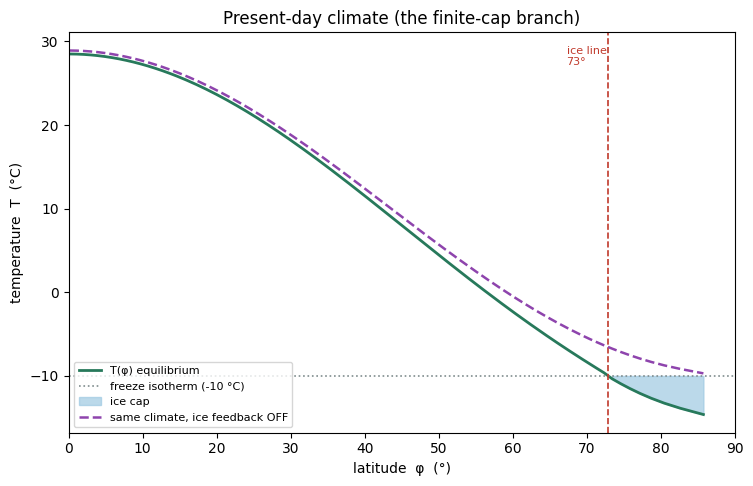

S₀ 1365 · A 210 · D 0.555  →  T̄ 14.70 °C · ice line 72.9° · net-TOA +2.0e-07 W/m²
   max |ice-on − ice-off| = 4.92 °C   (the gap IS the ice-albedo feedback; → 0 when the planet goes ice-free)


In [2]:
def climate_profile_what_if(S0=S0_EARTH, A=A_OLR, D=D_TRANSPORT):
    # Present-day EBM climate (ice feedback ON) vs the SAME climate with the feedback OFF.
    # n_tau=0.01 (fine): the steady state carries an O(Δt) operator-splitting bias, so this is the
    # one place NOT to coarsen — the on↔off gap must be the ice feedback, not numerics.
    params = EBMParams(S0=float(S0), A=float(A), D=float(D))
    ice_on = present_day_climate(params, n_tau=0.01)
    # Ice feedback OFF: push the freeze isotherm below any temperature, so α never switches to ice.
    ice_off = present_day_climate(replace(params, T_freeze=-1000.0), n_tau=0.01)
    lat = ice_on.latitude_deg()

    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    profile_axes(ax, ice_on)
    ax.plot(lat, ice_off.T, "--", color="#8e44ad", lw=1.8, label="same climate, ice feedback OFF")
    ax.legend(fontsize=8, loc="lower left")
    plt.show()

    gap = float(np.max(np.abs(ice_on.T - ice_off.T)))
    print(f"S₀ {S0:.0f} · A {A:.0f} · D {D:.3f}  →  "
          f"T̄ {ice_on.global_mean_T:.2f} °C · ice line {ice_on.ice_line_lat:.1f}° · "
          f"net-TOA {ice_on.net_toa:+.1e} W/m²")
    print(f"   max |ice-on − ice-off| = {gap:.2f} °C   "
          f"(the gap IS the ice-albedo feedback; → 0 when the planet goes ice-free)")

# Direct render (static, banked in the .ipynb).
climate_profile_what_if()

In [3]:
# Live: brighten/dim the sun, add greenhouse (lower A), change the heat-transport efficiency D.
interact(
    climate_profile_what_if,
    S0=widgets.FloatSlider(value=S0_EARTH, min=1200, max=1500, step=10,
                           description="S₀ W/m²", continuous_update=False),
    A=widgets.FloatSlider(value=A_OLR, min=190, max=220, step=2,
                          description="OLR A (lower=warmer)", continuous_update=False),
    D=widgets.FloatSlider(value=D_TRANSPORT, min=0.10, max=1.20, step=0.05,
                          description="transport D", continuous_update=False),
);

interactive(children=(FloatSlider(value=1365.2, continuous_update=False, description='S₀ W/m²', max=1500.0, mi…

## 2 — The Snowball bifurcation: one knob, two climates

Hidden inside that climate is a **bistability**. Dim the sun slowly and the ice cap creeps
equatorward — then past a threshold the ice-albedo feedback runs away and the **whole planet freezes
in a catastrophic jump** (Snowball Earth). Brighten it back and the white planet reflects so much
that it **stays frozen far past where it froze** — a wide hysteresis loop, *two stable climates for
one sun*.

This is the banked payoff and the integration test of every §1 piece (transport + the Strang-split
radiation + the feedback). It is a **parameter-continuation sweep** — ~120 equilibria, each
warm-started from the last — so it is **static, not a live slider**: a single `S₀` is a point, and
you need the whole loop to *see* the hysteresis. (The ★ is present-day Earth on the finite-cap
branch — a near-ice-free climate is also stable at today's sun.)

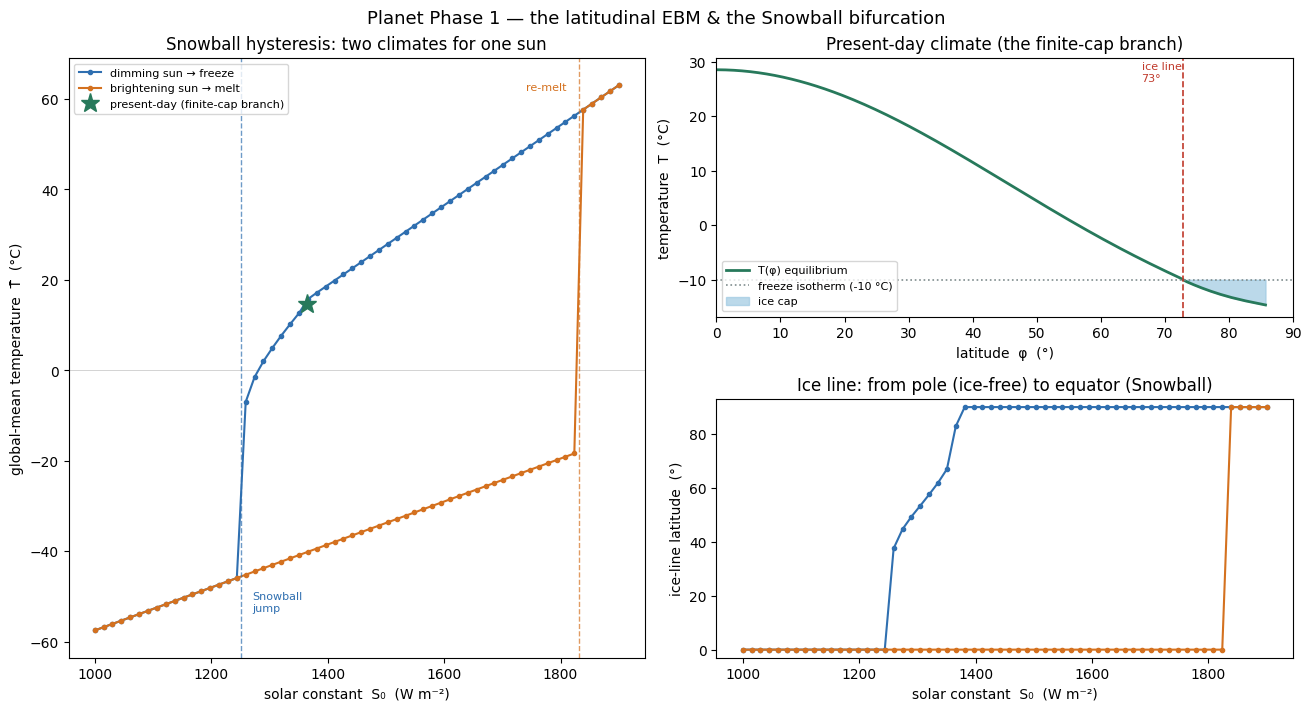

present-day:  T̄ 14.70 °C, ice line 72.9° (finite-cap branch; a near-ice-free climate is ALSO stable today)
freezes when dimmed to  S₀ ≈ 1252 W/m²  (−8.3%);  re-melts only at  S₀ ≈ 1831 W/m²   (hysteresis width 580 W/m²)
Snowball global-mean temperature: -57.5 °C  (a frozen white planet)


In [4]:
# The banked payoff: the full continuation sweep (dim → freeze, brighten → re-melt). ~3 s, static.
r = demo_snowball.compute()
snowball_figure(r.loop, r.present)
plt.show()
print(f"present-day:  T̄ {r.present.global_mean_T:.2f} °C, ice line {r.present_ice_line:.1f}° "
      f"(finite-cap branch; a near-ice-free climate is ALSO stable today)")
print(f"freezes when dimmed to  S₀ ≈ {r.freeze_S0:.0f} W/m²  (−{r.freeze_dimming_pct:.1f}%);  "
      f"re-melts only at  S₀ ≈ {r.melt_S0:.0f} W/m²   (hysteresis width {r.hysteresis_width:.0f} W/m²)")
print(f"Snowball global-mean temperature: {r.snowball_Tbar:.1f} °C  (a frozen white planet)")

## 3 — Climate → habitability: the biome map

Now the payoff the whole capstone builds toward. The climate state — the EBM temperature `T(φ)` and
a diagnostic precipitation `P(φ)` (`precip`: a circulation-set latitude pattern × a Clausius–Clapeyron
moisture amplitude) — is mapped through the **Whittaker classifier** (`biomes`) into a **biome at
every latitude**: tropical rain forest at the equator, the great deserts and savanna in the
subtropics, temperate forest in the midlatitudes, then boreal forest and tundra toward the poles.

*Planetary knobs in, bands of life out* — the planet analogue of Steel's microstructure and Chip's
device. And the bands **migrate as the knobs turn**: add greenhouse forcing (a CO₂ increase ≈ a
**lower** OLR offset `A`; a doubling ≈ 4 W/m²) and the tropics expand while the tundra retreats
poleward. The right panel is the *mechanism* — the Whittaker `(T, P)` plane with the planet's
equator→pole trajectory drawn through it, showing **why** the warm, dry subtropics land in desert.

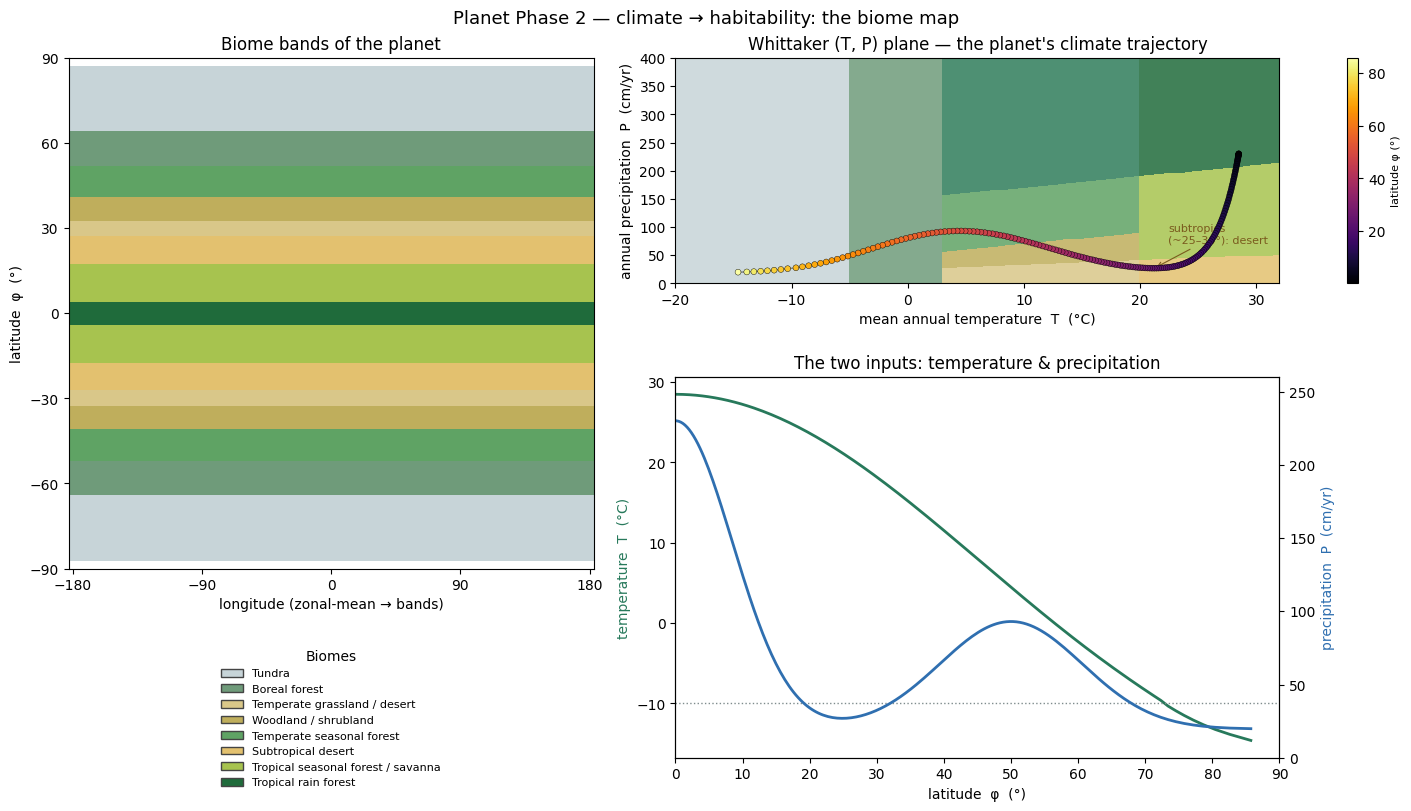

S₀ 1365 · CO₂ warming (−A) 0 W/m²  →  T̄ 14.70 °C · ice line 72.9°
   tropical rain forest 7.2% of the planet · tundra 10.0% · area fractions sum to 1.0000  (the map tiles the planet)


In [5]:
def biome_what_if(S0=S0_EARTH, co2_warming=0.0):
    # Climate → precip → biomes (demo_biomes.compute, the validated end-to-end map).
    # CO₂ up ≈ a drop in the OLR offset A. demo_biomes.compute uses the fine present-day n_tau internally.
    params = EBMParams(S0=float(S0), A=A_OLR - float(co2_warming))
    r = demo_biomes.compute(params)
    biomes_figure(r.state, r.precip_cm, r.codes)
    plt.show()

    rainforest = 100.0 * r.fraction(Biome.TROPICAL_RAIN_FOREST)
    tundra = 100.0 * r.fraction(Biome.TUNDRA)
    print(f"S₀ {S0:.0f} · CO₂ warming (−A) {co2_warming:.0f} W/m²  →  "
          f"T̄ {r.state.global_mean_T:.2f} °C · ice line {r.state.ice_line_lat:.1f}°")
    print(f"   tropical rain forest {rainforest:.1f}% of the planet · tundra {tundra:.1f}% · "
          f"area fractions sum to {sum(r.area_fractions.values()):.4f}  (the map tiles the planet)")

# Direct render (static, banked).
biome_what_if()

In [6]:
# Live: dim/brighten the sun, and crank the greenhouse — watch the biome bands migrate poleward.
interact(
    biome_what_if,
    S0=widgets.FloatSlider(value=S0_EARTH, min=1250, max=1450, step=10,
                           description="S₀ W/m²", continuous_update=False),
    co2_warming=widgets.FloatSlider(value=0.0, min=0.0, max=12.0, step=1.0,
                                    description="CO₂ warm (−A)", continuous_update=False),
);

interactive(children=(FloatSlider(value=1365.2, continuous_update=False, description='S₀ W/m²', max=1450.0, mi…

## 4 — The deep end: the interactive globe

The biome map above is *latitude bands* (a v1 **zonal-mean** planet). Its deep-end successor is
`projects/planet/planetmap.py` — a **Plotly 3-D globe** painted from a layer registry, with live
`S₀ / CO₂` sliders that recompute the climate and repaint the world. It is opt-in (a separate
`[webviz]` extra: `pip install -e .[webviz]`) so this matplotlib notebook stays light, and ships a
*pin-the-schema* exporter (`planet_spec.py`) whose round-trip-identity test is the deep end's one
real correctness property. Obliquity and vector (wind) overlays are named-but-deferred seams; the
inert elevation field is the extensibility proof.

> **What's next.** Phase 3 adds the project's **second shared engine** — a single-layer
> shallow-water / fluid solver — so the planet gains *winds*, the first thing that would let precip
> be **derived** rather than prescribed. Phase 4 couples it back to the climate (a one-way coupler).

## Where the numbers come from

Nothing here is fit in the notebook — every value is produced by a module validated in isolation,
each behind its own test triad (an analytic limit, a conservation/consistency law, a published
benchmark):

| Step | Module | Anchored to |
|---|---|---|
| Climate (EBM) | `ebm`, `albedo` | North (1975) **two-mode** analytic solution (~2nd order in Δx); global energy balance ⟨S(1−α)⟩ = A + B⟨T⟩ (net-TOA ~0); climlab present-day ice line ~70° |
| Snowball | `albedo`, `demo_snowball` | hysteresis **existence & structure** (two branches, a catastrophic jump, re-melt later than freeze); Voigt–Marotzke GCM dimming threshold 6–9% |
| Precipitation | `precip` | ITCZ-wet / subtropics-dry / midlat-wet / poles-dry band structure; **monotone** ⟨P⟩(T̄); Clausius–Clapeyron ~7 %/K (moisture capacity) |
| Biomes | `biomes` | **total partition** (area fractions sum to 1); independent canonical **probe points**; observed equator→pole band ordering |

The transport term reuses the **same frozen `engines/diffusion` solver** that cooled Steel's Jominy
bar and diffused Chip's dopant — here as a sphere's pole-to-equator heat transport — and the
radiation is grafted on with the **same Strang-splitting idiom** Steel's Jominy used for its lateral
heat loss. Per [ADR 0002](../../docs/decisions/0002-visualization-and-ux.md) the figures above are
*reach*, not evidence: the triads test the numbers, then we draw them.

Run the full validation suite for planet with `python -m tools.gate planet`, or the demos for the
publication-quality static figures (`python -m projects.planet.demo_snowball`,
`python -m projects.planet.demo_biomes`).